# Supplementary Figure S3B — Score calibration, H-bond parameters (G·C cWW)

Reference distributions of the three H-bond parameters, shaded by penalty severity.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import Polygon

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
BP_TYPE, LW_CLASS = "G-C", "cWW"


HB_PARAMS = ["distance", "donor_angle", "acceptor_angle"]


HB_UNITS = {"distance": "Å", "donor_angle": "°", "acceptor_angle": "°"}


FLIP = {"shear", "stagger", "buckle"}


PROSCO_PREFERRED = 5.0


CMAP = LinearSegmentedColormap.from_list("sev", ["0.82", "#F4D03F", "#E67E22", "#C0392B"])


PROSCO = json.load(open(data_file("reference/scoring_tables/prosco_distributions.json")))["prosco_distributions"]


ZTAB = json.load(open(data_file("reference/scoring_tables/z_tables.json")))


def load_features(kind):
    """kind='pairs' or 'hbonds' -> the G-C cWW rows of that reference feature table."""
    df = pd.read_csv(data_file(f"reference/high_quality_features/{kind}.csv"))
    return df[(df["bp_type"] == BP_TYPE) & (df["lw_class"] == LW_CLASS)].reset_index(drop=True)


def per_pdb_weights(pdb_ids):
    counts = pdb_ids.value_counts()
    return np.array([1.0 / counts[p] for p in pdb_ids])


def weighted_quantile(values, weights, q):
    order = np.argsort(values)
    v, w = values[order], weights[order]
    cum = np.cumsum(w)
    return float(np.interp(q * cum[-1], cum - w / 2, v))


def _to_cg(param, xs):                          # G-C frame -> stored C-G frame
    return -xs if param in FLIP else xs


def prosco_at(group, param, xs_gc):
    xs = _to_cg(param, xs_gc)
    c = PROSCO[group][param].get("C-G/cWW") or PROSCO[group][param].get("G-C/cWW")
    lo, hi, n = c["support_lo"], c["support_hi"], c["n_bins"]
    pb = np.array(c["prosco_per_bin"], float)
    idx = np.clip(((xs - lo) / (hi - lo) * n).astype(int), 0, n - 1)
    return pb[idx]


def zprime_at(group, param, xs_gc):
    xs = _to_cg(param, xs_gc)
    c = ZTAB[group][param].get("C-G/cWW") or ZTAB[group][param].get("G-C/cWW")
    M, sl, su = c["M"], c["sl"], c["su"]
    return (xs - M) / np.where(xs >= M, su, sl)


def severity_at(group, param, xs_gc):           # Cerny: 0 if ProSco>=5 else min(1,|Z'|/5)
    pr = prosco_at(group, param, xs_gc)
    z = zprime_at(group, param, xs_gc)
    return np.where(pr >= PROSCO_PREFERRED, 0.0, np.minimum(1.0, np.abs(z) / 5.0))


def _support_gc(group, param):
    c = PROSCO[group][param].get("C-G/cWW") or PROSCO[group][param].get("G-C/cWW")
    lo, hi = c["support_lo"], c["support_hi"]
    return (-hi, -lo) if param in FLIP else (lo, hi)


def _frame_xlim(group, param, med):
    """Widen x to span the gray->yellow->red transition (full red on both sides)."""
    s_lo, s_hi = _support_gc(group, param)
    xf = np.linspace(s_lo, s_hi, 4000)
    sf = severity_at(group, param, xf)
    L = xf[(xf < med) & (sf >= 0.999)]
    R = xf[(xf > med) & (sf >= 0.999)]
    xlo = L.max() if L.size else s_lo
    xhi = R.min() if R.size else s_hi
    pad = 0.06 * (xhi - xlo)
    return xlo - pad, xhi + pad


def render_cal(df, weights, params, units, group, ncols, title, colorbar=True):
    """Reference-KDE panel with the ProSco/Z' severity gradient clipped under each curve."""
    nrows = int(np.ceil(len(params) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.3 * nrows),
                             gridspec_kw={"hspace": 0.45, "wspace": 0.22})
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.0)
    norm = Normalize(0, 1)
    for ax, p in zip(np.atleast_1d(axes).flat, params):
        arr = df[p].to_numpy()
        finite = np.isfinite(arr)
        arr, w = arr[finite], weights[finite]
        med = weighted_quantile(arr, w, 0.5)
        fit_lo, fit_hi = weighted_quantile(arr, w, 0.005), weighted_quantile(arr, w, 0.995)
        in_r = (arr >= fit_lo) & (arr <= fit_hi)
        kde = gaussian_kde(arr[in_r], weights=w[in_r])
        xlo, xhi = _frame_xlim(group, p, med)
        xs = np.linspace(xlo, xhi, 600)
        ys = kde(xs)
        ymax = ys.max() * 1.10
        sev = severity_at(group, p, xs)
        grad = CMAP(norm(sev))[np.newaxis, :, :]
        im = ax.imshow(grad, extent=(xlo, xhi, 0, ymax), origin="lower",
                       aspect="auto", interpolation="bilinear", zorder=0)
        verts = np.vstack([[xlo, 0], np.column_stack([xs, ys]), [xhi, 0]])
        clip = Polygon(verts, closed=True, facecolor="none", edgecolor="none", zorder=0)
        ax.add_patch(clip)
        im.set_clip_path(clip)
        ax.plot(xs, ys, color="0.15", lw=1.8, zorder=2)
        ax.axvline(med, color="0.15", ls="--", lw=1, zorder=2)
        ax.set_xlim(xlo, xhi)
        ax.set_ylim(0, ymax)
        ax.set_yticks([])
        ax.set_title(f"{p.replace('_', ' ')}  ({units[p]})")
        ax.set_ylabel("weighted density")
        ax.set_xlabel(p.replace("_", " "))
    for ax in np.atleast_1d(axes).flat[len(params):]:
        ax.set_visible(False)
    if colorbar:
        sm = ScalarMappable(norm=norm, cmap=CMAP)
        sm.set_array([])
        cb = fig.colorbar(sm, ax=np.atleast_1d(axes).ravel().tolist(), fraction=0.025, pad=0.02)
        cb.set_label("penalty severity")
        cb.set_ticks([0, 0.5, 1.0])
        cb.set_ticklabels(["0\npreferred\n(ProSco>=5)", "0.5", "1\nfull\n(|Z'|>=5)"])
    return fig

G-C cWW GOOD H-bonds: 237,216, effective n = 887 PDBs


saved figures/figS3_B_hbond_calibration.png


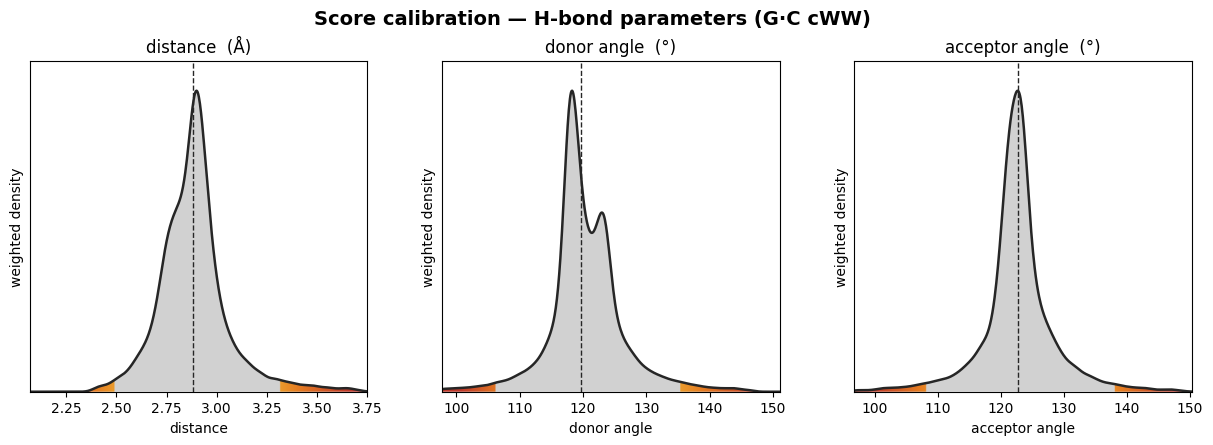

In [3]:
df = load_features("hbonds")
w = per_pdb_weights(df["pdb_id"])
print(f"G-C cWW GOOD H-bonds: {len(df):,}, effective n = {w.sum():.0f} PDBs")
fig = render_cal(df, w, HB_PARAMS, HB_UNITS, "hbonds", 3,
                     "Score calibration — H-bond parameters (G\u00b7C cWW)", colorbar=False)
print("saved", savefig(fig, "figS3_B_hbond_calibration.png"))
plt.show()